<a href="https://colab.research.google.com/github/SinhaPushkar047/ML_Learning_Projects/blob/main/01-Walmart-Linear-Regression/Walmart_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PowerTransformer

In [78]:
walmart=pd.read_csv('/content/Walmart_Sales.csv')

In [79]:
walmart['Date']=pd.to_datetime(walmart['Date'],format='%d-%m-%Y')

# **EDA**

In [80]:
walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [81]:
walmart.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


In [82]:
walmart.corr(numeric_only=True)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store,1.000000e+00,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176
Holiday_Flag,-4.386841e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000


<Axes: xlabel='CPI', ylabel='Count'>

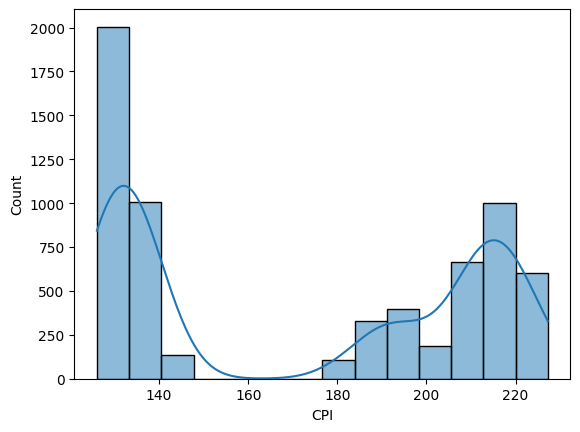

In [83]:
sns.histplot(data=walmart['CPI'],kde=True)

<Axes: xlabel='Weekly_Sales', ylabel='Count'>

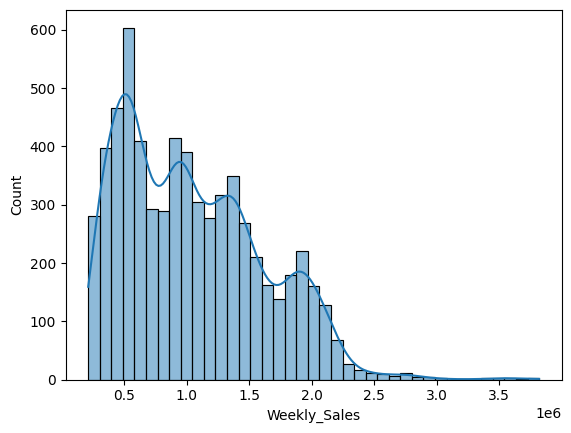

In [84]:
sns.histplot(data=walmart['Weekly_Sales'],kde=True)

<Axes: xlabel='Unemployment', ylabel='Count'>

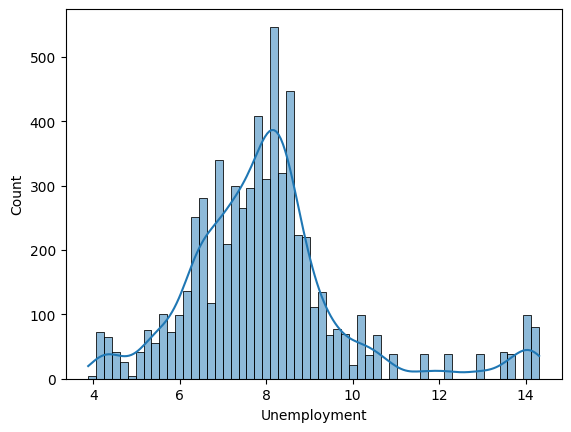

In [85]:
sns.histplot(data=walmart['Unemployment'],kde=True)

<Axes: xlabel='Fuel_Price', ylabel='Count'>

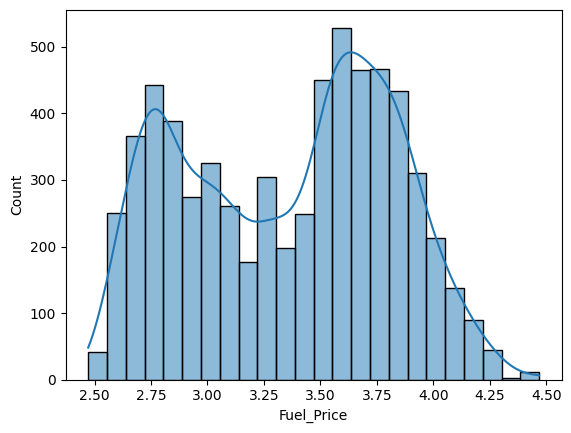

In [86]:
sns.histplot(data=walmart['Fuel_Price'],kde=True)

<Axes: xlabel='Temperature', ylabel='Count'>

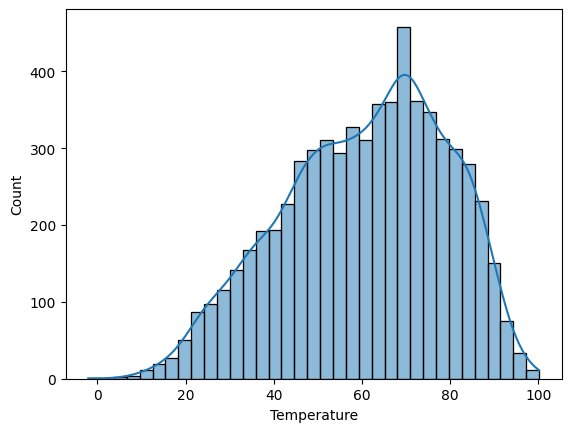

In [87]:
sns.histplot(data=walmart['Temperature'],kde=True)

In [88]:
walmart['Holiday_Flag'].value_counts()

,count
Holiday_Flag,
0,5985
1,450


In [89]:
col=[col for col in walmart.columns if col not in ['Weekly_Sales','Store','Date']]

In [90]:
col

['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

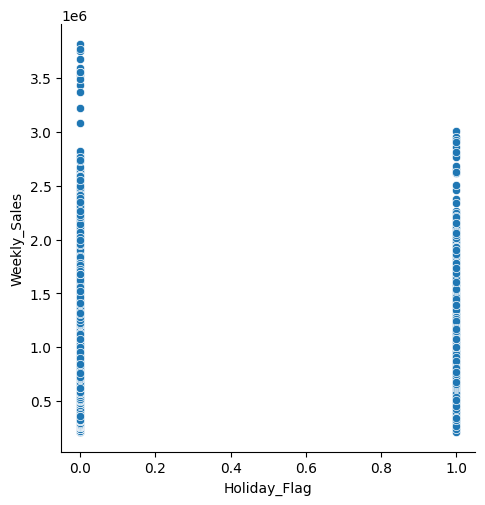

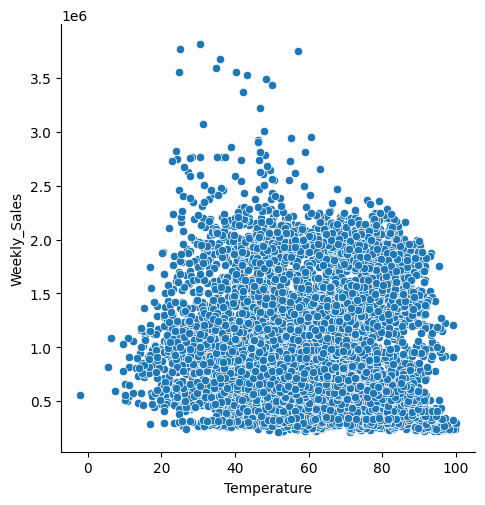

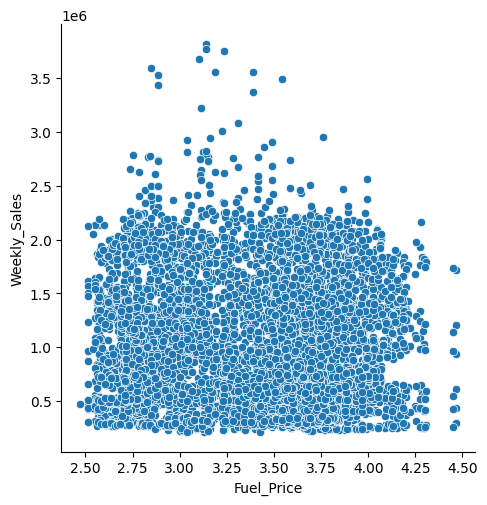

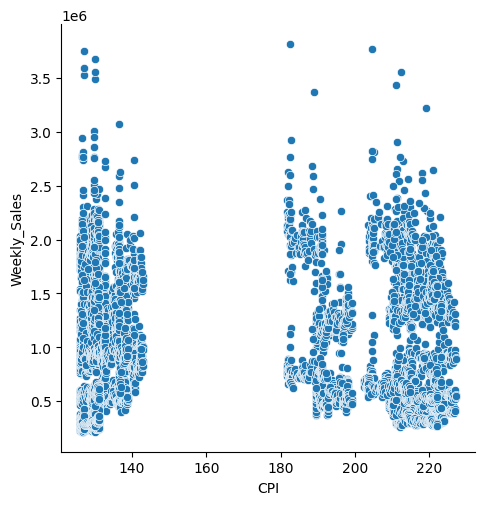

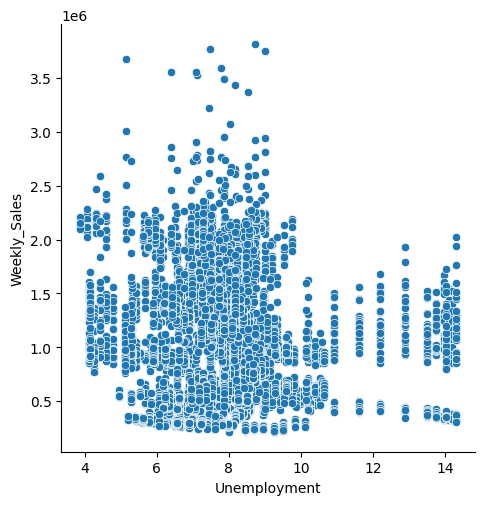

In [91]:
for i in col:
  g=sns.PairGrid(walmart,x_vars=i,y_vars='Weekly_Sales',height=5)
  g.map(sns.scatterplot)

# **Checking For Outliers**

<Axes: ylabel='CPI'>

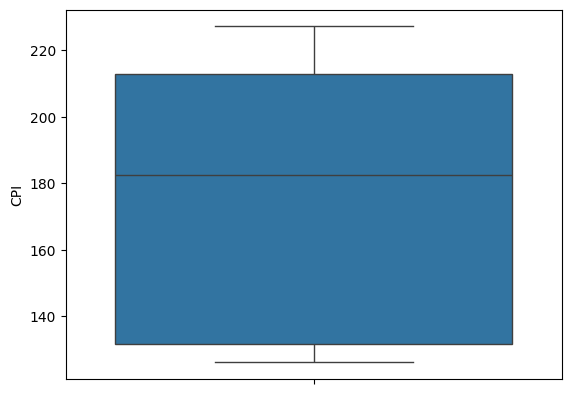

In [92]:
sns.boxplot(walmart['CPI'])

<Axes: ylabel='Unemployment'>

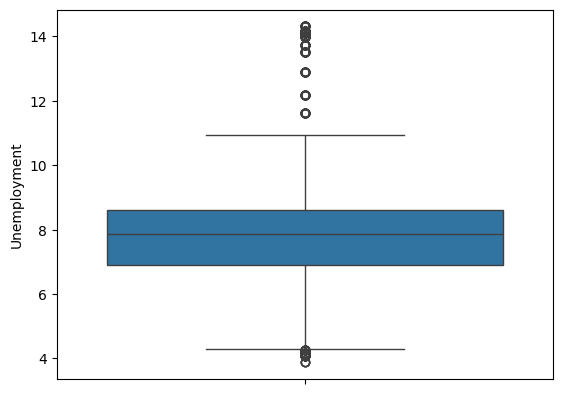

In [93]:
sns.boxplot(walmart['Unemployment'])

<Axes: ylabel='Temperature'>

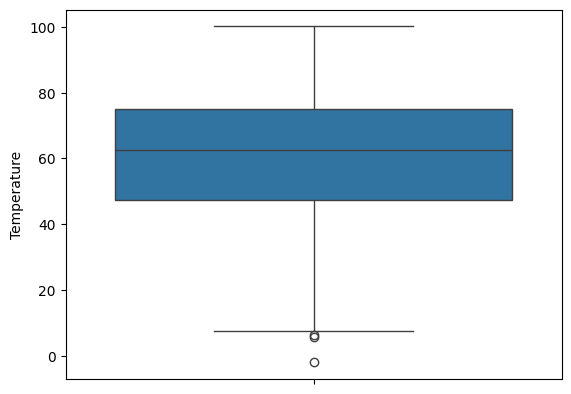

In [94]:
sns.boxplot(walmart['Temperature'])

<Axes: ylabel='Fuel_Price'>

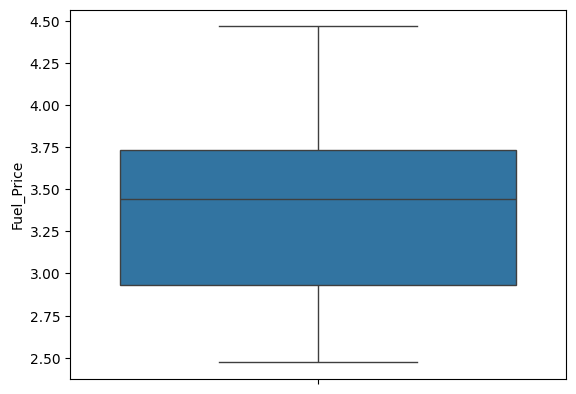

In [95]:
sns.boxplot(walmart['Fuel_Price'])

# **Checking Outlier in Temperature Column A/Boxplot**

In [96]:
q1=walmart['Temperature'].quantile(0.25)
q3=walmart['Temperature'].quantile(0.75)
iqr= q3-q1
lower= q1-1.5*iqr
upper=q3+1.5*iqr
outlier=walmart[
    (walmart['Temperature']>upper) |
    (walmart['Temperature']<lower)
]
outlier

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
910,7,2011-02-04,558027.77,0,-2.06,3.011,191.762589,8.818
2336,17,2011-01-07,1083071.14,0,6.23,2.891,127.191774,6.866
3626,26,2011-01-28,817485.14,0,5.54,3.243,133.105968,7.907


# **Checking Outlier in Unemployment Column A/Boxplot**

In [97]:
Q1 = walmart['Unemployment'].quantile(0.25)
Q3 = walmart['Unemployment'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = walmart[
    (walmart['Unemployment'] < lower) |
    (walmart['Unemployment'] > upper)
]

outliers.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,481.000000,481,4.810000e+02,481.000000,481.00000,481.000000,481.000000,481.000000
mean,26.205821,2011-07-18 09:43:47.027026944,9.983297e+05,0.066528,65.29659,3.596426,130.182567,11.447480
min,4.000000,2010-02-05 00:00:00,3.039088e+05,0.000000,14.02000,2.825000,126.064000,3.879000
25%,12.000000,2010-11-12 00:00:00,4.577117e+05,0.000000,52.06000,3.145000,126.606645,11.627000
50%,28.000000,2011-08-19 00:00:00,1.016040e+06,0.000000,64.55000,3.692000,129.240581,13.503000
75%,38.000000,2012-03-30 00:00:00,1.270037e+06,0.000000,81.06000,3.909000,130.959226,14.021000
max,40.000000,2012-10-26 00:00:00,2.283540e+06,1.000000,99.22000,4.294000,138.911700,14.313000
std,11.214446,NaN,4.542217e+05,0.249462,17.69733,0.410592,3.993930,3.891387


<Axes: xlabel='Unemployment', ylabel='Weekly_Sales'>

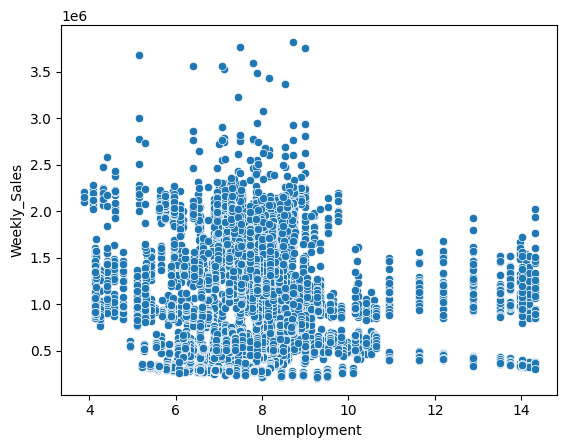

In [98]:
sns.scatterplot(walmart,x=walmart['Unemployment'],y=walmart['Weekly_Sales'])

# **Train Test Split**

In [99]:
x_train,x_test,y_train,y_test= train_test_split(
    walmart.drop(columns=['Weekly_Sales','Date']),walmart['Weekly_Sales'],test_size=0.2,random_state=42)

# **PreProcessing**

In [100]:
x_train.sample()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
569,4,0,57.11,3.603,131.108333,3.879


In [101]:
trf1=ColumnTransformer([
    ('scale_temp',StandardScaler(),[2,3,4,5]),
],remainder='passthrough')

In [102]:
trf2=ColumnTransformer([
    ('enc_store',OneHotEncoder(handle_unknown='ignore',sparse_output=False),[4])
],remainder='passthrough')

In [103]:
trf3=ColumnTransformer([
    ('cpi_trf',PowerTransformer(),[47]),
    ('fuel_price_trf',PowerTransformer(),[46]),
    ('temp_trf',PowerTransformer(),[45])
],remainder='passthrough')

In [104]:
pipe=make_pipeline(trf1,trf2,trf3)

In [105]:
x_train_trf=pipe.fit_transform(x_train)
x_test_trf=pipe.transform(x_test)

# **Model Train**

In [106]:
lr=LinearRegression()

In [107]:
lr.fit(x_train_trf,y_train)

LinearRegression()

In [108]:
y_pred=lr.predict(x_test_trf)

# **Checking Accuracy**

In [109]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.9210247664525659


In [110]:
scores = cross_val_score(
    lr,
    x_train_trf,
    y_train,
    cv=5,
    scoring='r2'
)

print("CV scores:", scores)
print("Mean CV R²:", scores.mean())

CV scores: [0.91557776 0.92451004 0.91447284 0.90917324 0.92673081]
Mean CV R²: 0.9180929387284061


In [111]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

MAE: 91010.48985454933
RMSE: 159506.2129834479


# **Ploting y_test and y_pred**

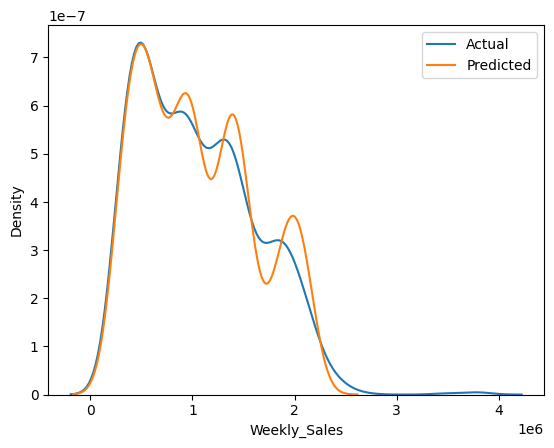

In [112]:
sns.kdeplot(y_test,label='Actual')
sns.kdeplot(y_pred,label='Predicted')
plt.legend()
plt.show()